10


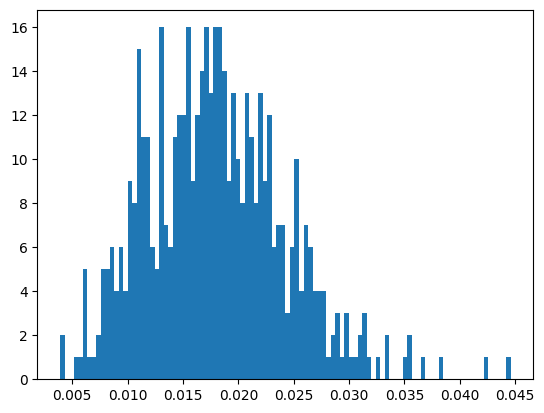

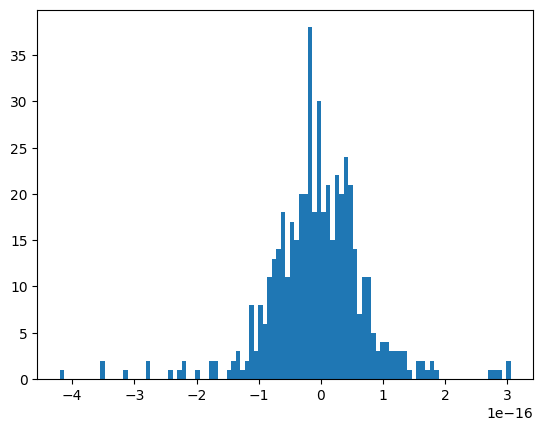

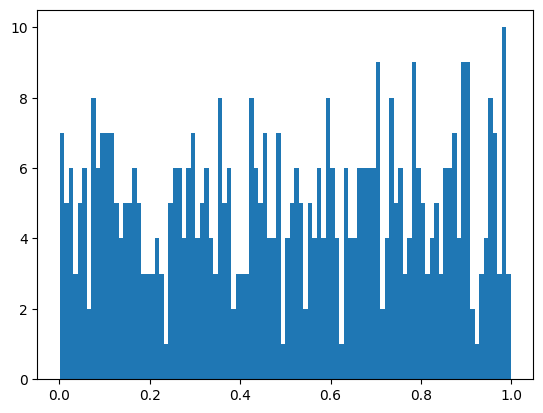

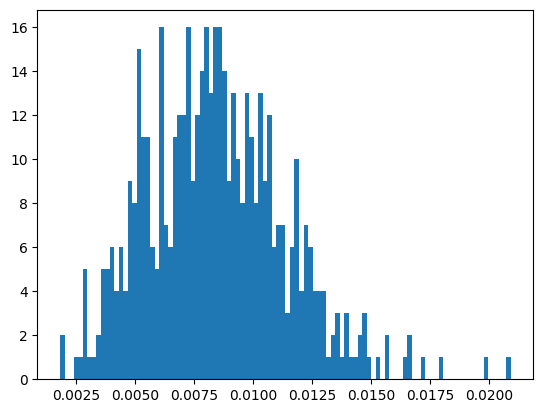

This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
No row reduction nee

ValueError: Found array with dim 3, while dim <= 2 is required by LinearRegression.

In [1]:
##### Script to perform the simulation study
import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")
folder = "rho0.30_p500_n100_k10"

## initialize lists to store data
df_train = []
df_test = []
y_train = []
y_test = []

## read in the simulation data
for i in range(5):
    df_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/X_train.csv")
    )
    df_test.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/X_test.csv")
    )
    y_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/y_train.csv")
    )
    y_test.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/y_test.csv")
    )

## set the seed
random.seed(1)

## set the basis parameters
k = 10
print(k)

## Calculate the scores per data frame
column_ls = []
column_cls = []
column_rs = []
column_cs = []

for i in range(5):
    column_ls.append(get_leverage_scores(df_train[i], k))
    column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
    column_rs.append(get_random_scores(df_train[i]))
    column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))

## Investigation of distributions
plt.hist(column_ls[0], bins=100)
plt.show()
plt.hist(column_cls[0], bins=100)
plt.show()
plt.hist(column_rs[0], bins=100)
plt.show()
plt.hist(column_cs[0], bins=100)
plt.show()

## Calculation of column reduction
C_ls = []
C_cls = []
C_rs = []
C_cs = []

for i in range(5):
    C_ls.append(column_reduction(df_train[i], column_ls[i], k))
    C_cls.append(column_reduction(df_train[i], column_cls[i], k))
    C_rs.append(column_reduction(df_train[i], column_rs[i], k))
    C_cs.append(column_reduction(df_train[i], column_cs[i], k))

## Calculation of row reduction
R_ls = []
R_cls = []
R_rs = []
R_cs = []

for i in range(5):
    R_ls.append(row_reduction(C_ls[i]['C'], k))
    R_cls.append(row_reduction(C_cls[i]['C'], k))
    R_rs.append(row_reduction(C_rs[i]['C'], k))
    R_cs.append(row_reduction(C_cs[i]['C'], k))

## Fit linear models to the reduced data matrix
model_ls = []
for i in range(1):
    model = LinearRegression()
    print(R_ls[i]['R'])
    print(y_train)
    model.fit(R_ls[i]['R'], y_train)
    model_ls.append(model)

predictions_ls = []
for i in range(5):
    predictions_ls.append(df_test[i][0].to_numpy())

rmse_ls = []
for i in range(5):
    rmse_ls.append(np.sqrt(mean_squared_error(y_test, predictions_ls[i])))